In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [2]:
df=sns.load_dataset("iris")

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
from sklearn.preprocessing import LabelEncoder
st=LabelEncoder()

In [9]:
df["species"]=st.fit_transform(df["species"])

In [11]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [14]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [15]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


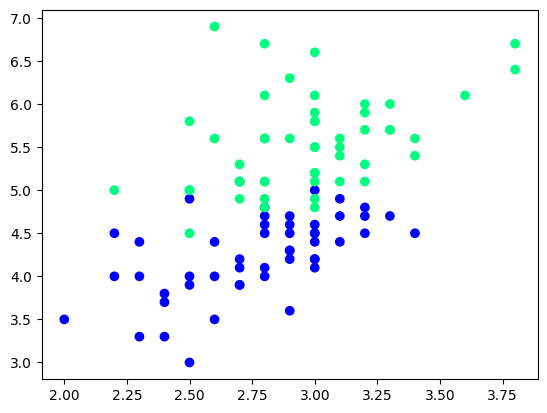

In [17]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [22]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal_width,petal_length,species
58,2.9,4.6,1
78,2.9,4.5,1
79,2.6,3.5,1
57,2.4,3.3,1
59,2.7,3.9,1
101,2.7,5.1,2
92,2.6,4.0,1
54,2.8,4.6,1
60,2.0,3.5,1
69,2.5,3.9,1


In [23]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [24]:
df_train

,sepal_width,petal_length,species
99,2.8,4.1,1
109,3.6,6.1,2
56,3.3,4.7,1
123,2.7,4.9,2
84,3.0,4.5,1
91,3.0,4.6,1
119,2.2,5.0,2
86,3.1,4.7,1
142,2.7,5.1,2
72,2.5,4.9,1


In [25]:
df_val

,sepal_width,petal_length,species
81,2.4,3.7,1
114,2.8,5.1,2
111,2.7,5.3,2
135,3.0,6.1,2
131,3.8,6.4,2


In [26]:
df_test

,sepal_width,petal_length,species
147,3.0,5.2,2
116,3.0,5.5,2
55,2.8,4.5,1
63,2.9,4.7,1
121,2.8,4.9,2


In [27]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

### Case 1 - Bagging

In [29]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
86,3.1,4.7,1
142,2.7,5.1,2
119,2.2,5.0,2
72,2.5,4.9,1
142,2.7,5.1,2
99,2.8,4.1,1
119,2.2,5.0,2
109,3.6,6.1,2


In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [36]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

In [37]:
dt_bag1 = DecisionTreeClassifier()

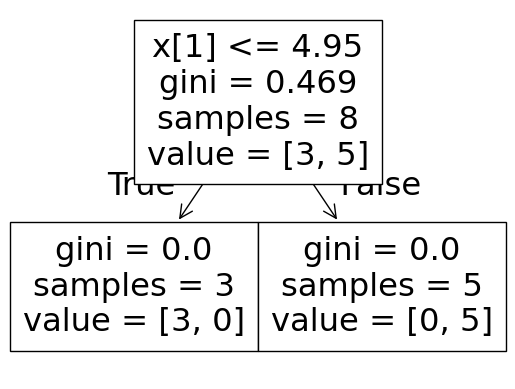

C:\Users\kaleg\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\kaleg\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


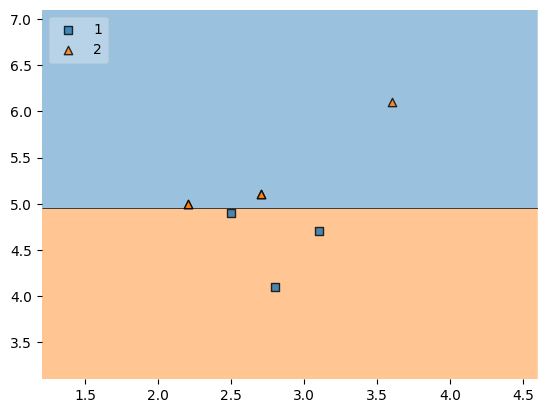

In [38]:
evaluate(dt_bag1,X,y)

In [41]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag


,sepal_width,petal_length,species
84,3.0,4.5,1
84,3.0,4.5,1
91,3.0,4.6,1
72,2.5,4.9,1
119,2.2,5.0,2
86,3.1,4.7,1
86,3.1,4.7,1
72,2.5,4.9,1


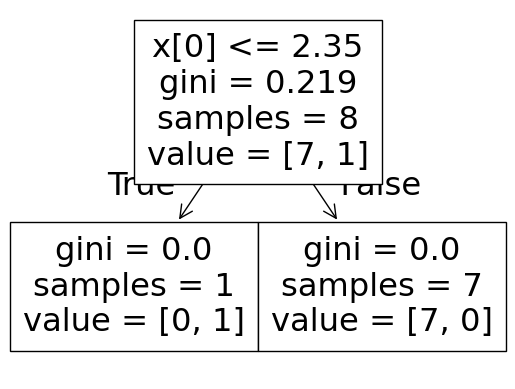

C:\Users\kaleg\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\kaleg\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.2


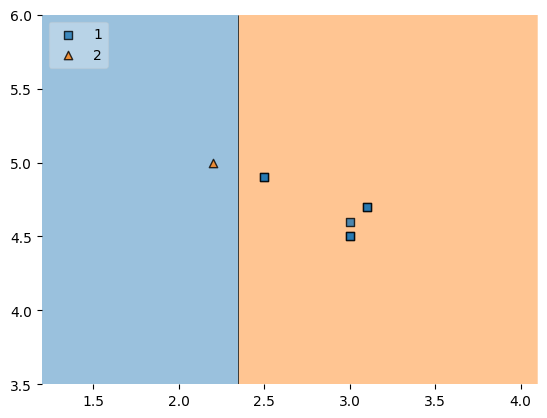

In [42]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [43]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
72,2.5,4.9,1
84,3.0,4.5,1
84,3.0,4.5,1
119,2.2,5.0,2
56,3.3,4.7,1
109,3.6,6.1,2
123,2.7,4.9,2
86,3.1,4.7,1


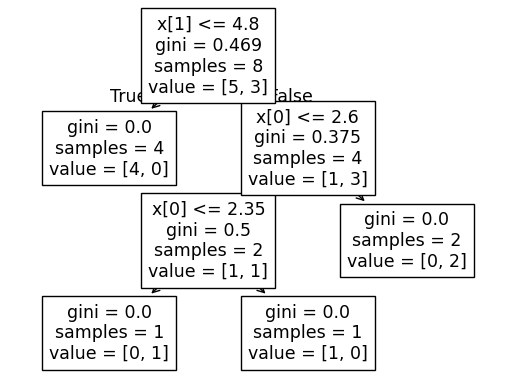

C:\Users\kaleg\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\kaleg\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


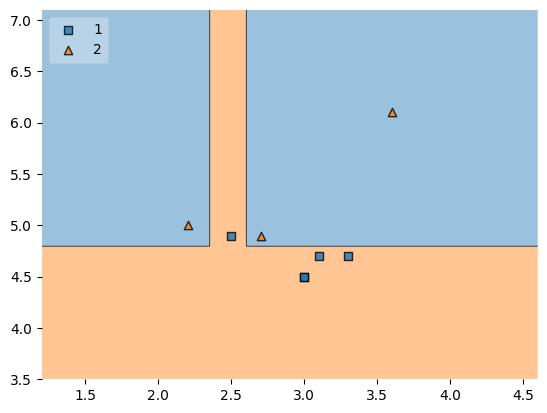

In [44]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

### Predict

In [39]:
df_test

,sepal_width,petal_length,species
147,3.0,5.2,2
116,3.0,5.5,2
55,2.8,4.5,1
63,2.9,4.7,1
121,2.8,4.9,2


In [45]:
print("Predictor 1",dt_bag1.predict(np.array([3.0,5.2]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([3.0,5.2]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([3.0,5.2]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [1]
Predictor 3 [2]


C:\Users\kaleg\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\kaleg\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\kaleg\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### Pasting

In [46]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
99,2.8,4.1,1
109,3.6,6.1,2
56,3.3,4.7,1
123,2.7,4.9,2
84,3.0,4.5,1
91,3.0,4.6,1
119,2.2,5.0,2
86,3.1,4.7,1
142,2.7,5.1,2
72,2.5,4.9,1


In [47]:
df_train.sample(8)

,sepal_width,petal_length,species
86,3.1,4.7,1
119,2.2,5.0,2
56,3.3,4.7,1
123,2.7,4.9,2
84,3.0,4.5,1
142,2.7,5.1,2
72,2.5,4.9,1
91,3.0,4.6,1


### Random Subspaces

In [50]:
df1 = sns.load_dataset("iris")
df1 = df1.sample(10)
df1

,sepal_length,sepal_width,petal_length,petal_width,species
81,5.5,2.4,3.7,1.0,versicolor
122,7.7,2.8,6.7,2.0,virginica
90,5.5,2.6,4.4,1.2,versicolor
37,4.9,3.6,1.4,0.1,setosa
55,5.7,2.8,4.5,1.3,versicolor
18,5.7,3.8,1.7,0.3,setosa
54,6.5,2.8,4.6,1.5,versicolor
143,6.8,3.2,5.9,2.3,virginica
15,5.7,4.4,1.5,0.4,setosa
100,6.3,3.3,6.0,2.5,virginica


In [51]:
df1.sample(2,replace=True,axis=1)

,species,sepal_width
81,versicolor,2.4
122,virginica,2.8
90,versicolor,2.6
37,setosa,3.6
55,versicolor,2.8
18,setosa,3.8
54,versicolor,2.8
143,virginica,3.2
15,setosa,4.4
100,virginica,3.3


### Random Patches

In [52]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
81,5.5,2.4,3.7,1.0,versicolor
122,7.7,2.8,6.7,2.0,virginica
90,5.5,2.6,4.4,1.2,versicolor
37,4.9,3.6,1.4,0.1,setosa
55,5.7,2.8,4.5,1.3,versicolor
18,5.7,3.8,1.7,0.3,setosa
54,6.5,2.8,4.6,1.5,versicolor
143,6.8,3.2,5.9,2.3,virginica
15,5.7,4.4,1.5,0.4,setosa
100,6.3,3.3,6.0,2.5,virginica


In [53]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,sepal_length,species
143,6.8,virginica
100,6.3,virginica
143,6.8,virginica
122,7.7,virginica
15,5.7,setosa
54,6.5,versicolor
100,6.3,virginica
100,6.3,virginica
